In [1]:
# ======================================================
# Import libraries, load dataset, clean data, and filter
# ======================================================

import ast                                   # Convert string representations into Python lists
import pandas as pd                          # Data analysis
import seaborn as sns                        # Better statistical visualizations
import matplotlib.pyplot as plt              # Plot customization
from datasets import load_dataset            # Load the Hugging Face dataset

# -------------------------
# Load dataset
# -------------------------
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# -------------------------
# Clean dataset
# -------------------------

# Convert posting dates into datetime objects
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

# Convert skill strings into actual Python lists
df["job_skills"] = df["job_skills"].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

# -------------------------
# Filter for U.S. Data Engineer jobs
# -------------------------
df_DE_US = df[
    (df["job_country"] == "United States") &
    (df["job_title_short"] == "Data Engineer")
].copy()

# Quick sanity check
df_DE_US.head()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,NaN,NaN,NaN,smart folks inc,"[python, sql, gcp]","{'cloud': ['gcp'], 'programming': ['python', '..."
11,Data Engineer,Data Engineer,"Colorado Springs, CO (+3 others)",via The Muse,Full-time,False,"Texas, United States",2023-11-03 13:06:51,False,True,United States,NaN,NaN,NaN,Philips,"[python, qlik]","{'analyst_tools': ['qlik'], 'programming': ['p..."
26,Data Engineer,Data Engineer,United States,via LinkedIn,Full-time,False,Georgia,2023-09-15 13:56:18,True,False,United States,NaN,NaN,NaN,Infinite Computer Solutions,NaN,NaN
27,Data Engineer,"Principal Data Engineer (Lead), Knowledge Grap...","San Francisco, CA",via LinkedIn,Full-time,False,Georgia,2023-02-18 13:31:24,False,False,United States,NaN,NaN,NaN,Altos Labs,"[python, r, java]","{'programming': ['python', 'r', 'java']}"


In [2]:
# =========================
# Prepare location data
# =========================

# Count the number of Data Engineer jobs in each location
df_plot = (
    df_DE_US["job_location"]
        .value_counts()
        .head(10)
        .to_frame(name="count")
)

# Display the table
df_plot

,count
job_location,
Anywhere,6285
"New York, NY",1212
United States,1111
"Dallas, TX",835
"Atlanta, GA",764
"Chicago, IL",714
"Austin, TX",619
"Washington, DC",611
"Charlotte, NC",599


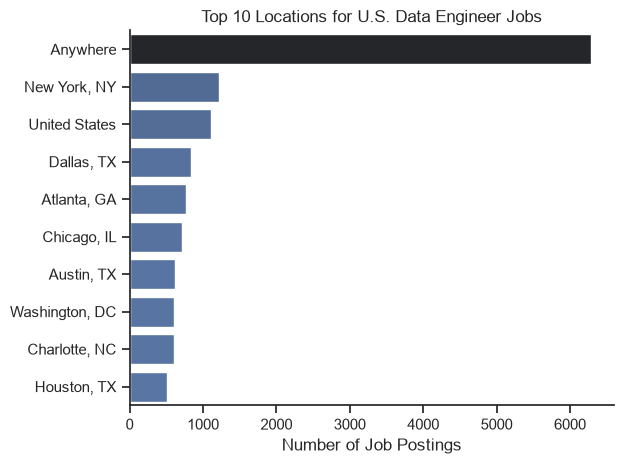

In [3]:
# =========================
# Plot top Data Engineer job locations
# =========================

# Use a clean Seaborn theme
sns.set_theme(style="ticks")

# Create horizontal bar chart
sns.barplot(
    data=df_plot,
    x="count",                     # Number of job postings
    y="job_location",              # Location names
    hue="count",                   # Color intensity represents job count
    palette="dark:b_r",            # Dark-to-light blue palette
    legend=False                   # Hide redundant legend
)

# Remove unnecessary top/right chart borders
sns.despine()

# Add title and labels
plt.title("Top 10 Locations for U.S. Data Engineer Jobs")
plt.xlabel("Number of Job Postings")
plt.ylabel("")

# Prevent labels from overlapping
plt.tight_layout()

# Display chart
plt.show()

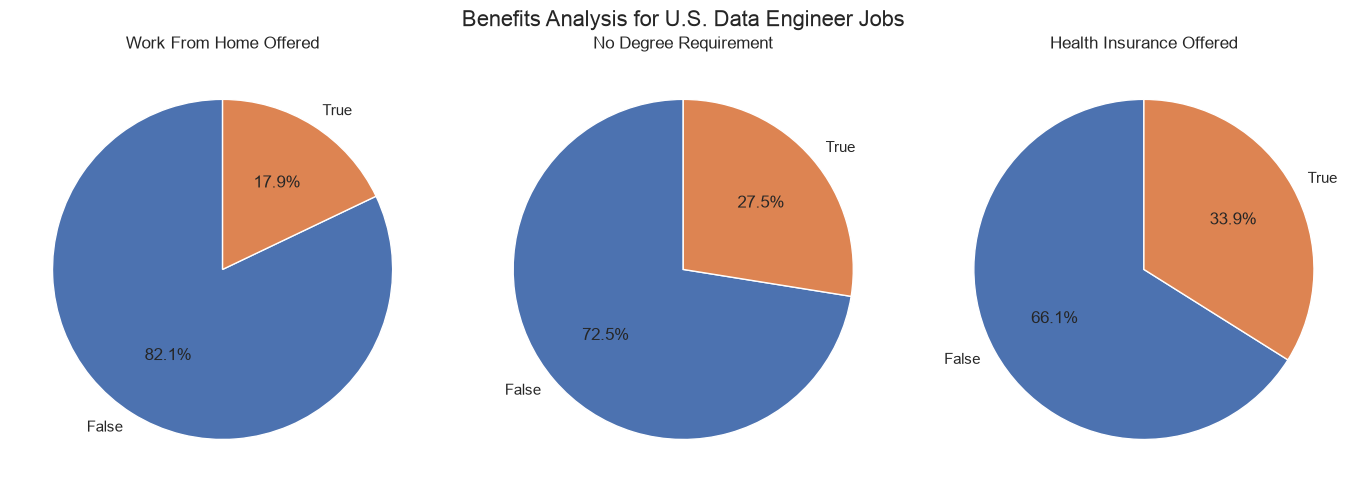

In [4]:
# ======================================================
# Benefits Analysis for U.S. Data Engineer Jobs
# ======================================================

# Dictionary:
# Key   = column in the dataset
# Value = title shown on each pie chart
benefit_columns = {
    "job_work_from_home": "Work From Home Offered",
    "job_no_degree_mention": "No Degree Requirement",
    "job_health_insurance": "Health Insurance Offered"
}

# Create 1 row with 3 charts
fig, ax = plt.subplots(1, 3)

# Set overall figure size (width, height)
fig.set_size_inches(14, 5)

# Loop through each benefit in the dictionary
for i, (column, title) in enumerate(benefit_columns.items()):

    # Count True vs False values and create a pie chart
    ax[i].pie(
        df_DE_US[column].value_counts(),     # Count True/False
        labels=["False", "True"],            # Labels on slices
        autopct="%1.1f%%",                   # Show percentages
        startangle=90                        # Rotate so chart starts at top
    )

    # Give each pie chart its own title
    ax[i].set_title(title)

# Overall dashboard title
plt.suptitle(
    "Benefits Analysis for U.S. Data Engineer Jobs",
    fontsize=16
)

# Prevent titles from overlapping
plt.tight_layout()

# Display dashboard
plt.show()

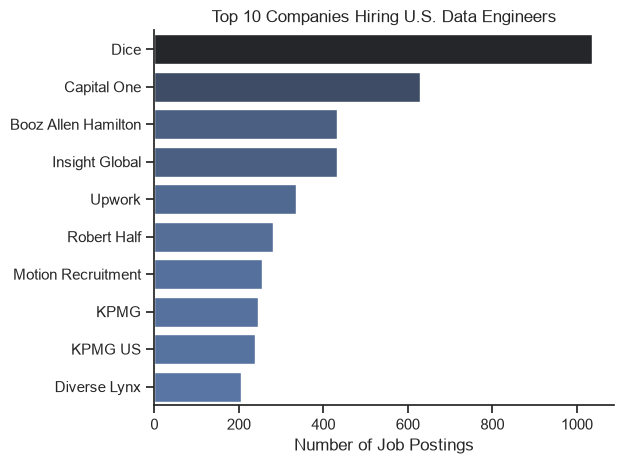

In [5]:
# ======================================================
# Top Companies Hiring U.S. Data Engineers
# ======================================================

# Count the number of job postings for each company
# Keep only the top 10 companies
# Convert the result into a DataFrame for Seaborn
df_plot = (
    df_DE_US["company_name"]
        .value_counts()
        .head(10)
        .to_frame(name="count")
)

# Use Seaborn's clean style
sns.set_theme(style="ticks")

# Create a horizontal bar chart
sns.barplot(
    data=df_plot,
    x="count",                  # Number of job postings
    y="company_name",           # Company names
    hue="count",                # Color intensity based on count
    palette="dark:b_r",         # Dark-to-light blue palette
    legend=False                # Hide unnecessary legend
)

# Remove top and right borders
sns.despine()

# Add chart title and labels
plt.title("Top 10 Companies Hiring U.S. Data Engineers")
plt.xlabel("Number of Job Postings")
plt.ylabel("")

# Prevent labels from overlapping
plt.tight_layout()


# Display the chart
plt.show()